<a href="https://colab.research.google.com/github/lujala01/lujala01.github.io/blob/main/HR_Attrition_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Human Resource Attrition Classification

# Data Understanding and Preparation

In [ ]:
# 1. Import necessary libraries
import pandas as pd # Loading, manipulating, and analyzing data
import numpy as np # Numerical operations and working with arrays
from pathlib import Path # Work with file system paths in an OS- independent way

from sklearn.model_selection import train_test_split # Import function that splits data into train and test sets
from sklearn.preprocessing import StandardScaler # Import function that standardize numeric features (mean=0, sd=1)
from sklearn.linear_model import LogisticRegression # Imports logistic regression algorithm
from sklearn.tree import DecisionTreeClassifier # Import decision tree classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # Imports ensemble algorithms
from sklearn.svm import SVC # Imports SVM algorithm for classification
from sklearn.neural_network import MLPClassifier # Imports multi layer perceptron a neural network based classifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
) # Imports evaluation metrics
import matplotlib.pyplot as plt # Import library for visualizations

pd.set_option("display.max_columns", None) # Tells pandas to display all columns when showing Dataframe

DATA_PATH= Path("/content/drive/MyDrive/Final_Project/WA_Fn-UseC_-HR-Employee-Attrition.csv")
assert DATA_PATH.is_file(), f"Cannot find {DATA_PATH}. Make sure the CSV is in the same folder as this notebook"

In [ ]:
# 2. Load and inspect the data
df= pd.read_csv(DATA_PATH)
df.head()
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


## EDA of the Dataset

In [ ]:
# Basic Structure and Summary
display(df.info()) # Concise summary of dataframe
display(df.describe (include="all")) # Descriptive statistics of dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

None

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,882,NaN,NaN,NaN,326,NaN,673,NaN,NaN,NaN,1470,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,NaN,65.891156,2.729932,2.063946,NaN,2.728571,NaN,6502.931293,14313.103401,2.693197,NaN,NaN,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,NaN,20.329428,0.711561,1.106940,NaN,1.102846,NaN,4707.956783,7117.786044,2.498009,NaN,NaN,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8047.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4919.000000,14235.500000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,NaN,83.750000,3.000000,3.000000,NaN,4.000000,NaN,8379.000000,20461.500000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


The average monthly income is $6,503, and employees have spent an average of 7 years with the company, which aligns with the relatively low attrition rate. The organization offers an average salary hike of 15%, with a minimum of 11%, which likely helps retain employees who value extrinsic rewards.
Internal satisfaction metrics like environmental satisfaction, job satisfaction, relationship satisfaction, and work–life balance, are measured on a 1–4 scale and average around 2.72, with a standard deviation of about 1 point, indicating mild variation. These measures are slightly negatively skewed, suggesting a greater concentration of responses on the lower end of the scale.
Performance ratings have a higher average score of 3.15 out of 4 with a low standard deviation of 0.36, indicating limited variation. The distribution is positively skewed, with a skewness value of 1.92.


In [ ]:
display(df['Attrition'].value_counts(normalize=True)) # Count occurance of unique values
display(df['BusinessTravel'].value_counts(normalize=True))
display(df['Department'].value_counts(normalize=True))
display(df['EducationField'].value_counts(normalize=True))
display(df['Gender'].value_counts(normalize=True))
display(df['JobRole'].value_counts(normalize=True))
display(df['MaritalStatus'].value_counts(normalize=True))
display(df['OverTime'].value_counts(normalize=True))

,proportion
Attrition,
No,0.838776
Yes,0.161224


,proportion
BusinessTravel,
Travel_Rarely,0.709524
Travel_Frequently,0.188435
Non-Travel,0.102041


,proportion
Department,
Research & Development,0.653741
Sales,0.303401
Human Resources,0.042857


,proportion
EducationField,
Life Sciences,0.412245
Medical,0.315646
Marketing,0.108163
Technical Degree,0.089796
Other,0.055782
Human Resources,0.018367


,proportion
Gender,
Male,0.6
Female,0.4


,proportion
JobRole,
Sales Executive,0.221769
Research Scientist,0.198639
Laboratory Technician,0.176190
Manufacturing Director,0.098639
Healthcare Representative,0.089116
Manager,0.069388
Sales Representative,0.056463
Research Director,0.054422
Human Resources,0.035374


,proportion
MaritalStatus,
Married,0.457823
Single,0.319728
Divorced,0.222449


,proportion
OverTime,
No,0.717007
Yes,0.282993


The dataset has 1470 observations with 35 attributes (26 numeric and 9 categoric) which don't have any missing values. 'EmployeeCount', 'StandardHours'and 'Over18' have same values across all observations so they don't contain any information to discriminate against the classes. Hence, they are subsequently dropped from the dataset.
Attributes has two values 'Yes' and 'No' with the former comprising 84% and later 16%. Business travel includes those who travel frequently (19%), rarely (71%) and non travellers (10%). Department includes 'Research & development' (65%), 'Sales' (30%) and 'Human resources'(5%). Education is dominated by 'Life Sciences'(41%) then 'Medical'(32%) while other degrees individually occupy about or less than 10%. Males employees occupy 60% , married employee occupy 46% as opposed to single occypying 32% and small portion around 28% work overtime. Sales Executives, Research scientist and laboratory technicians jointly accounts for 60% of total employees while rest are human resource,and sales related job roles.

In [ ]:
# Display distribution of numeric columns
numeric_cols= df.select_dtypes(include=np.number).columns.tolist()

# Calculate skewness of the numeric columns
skewness=df[numeric_cols].skew()
print("\nSkewness of Numeric Columns:")
print(skewness)


Skewness of Numeric Columns:
Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EmployeeCount               0.000000
EmployeeNumber              0.016574
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StandardHours               0.000000
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: f

'DailyRate', 'EmployeeNumber', 'HourlyRate' and 'MonthlyRate' have skewness score between -0.05 and 0.05. All other numerical variables have high skewness.

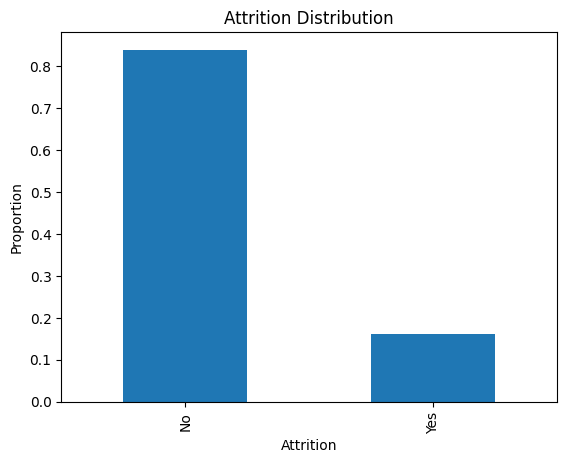

In [ ]:
# Plot bar chart of attrition column
plt.figure
df['Attrition'].value_counts(normalize=True).plot(kind='bar')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Proportion')
plt.show()

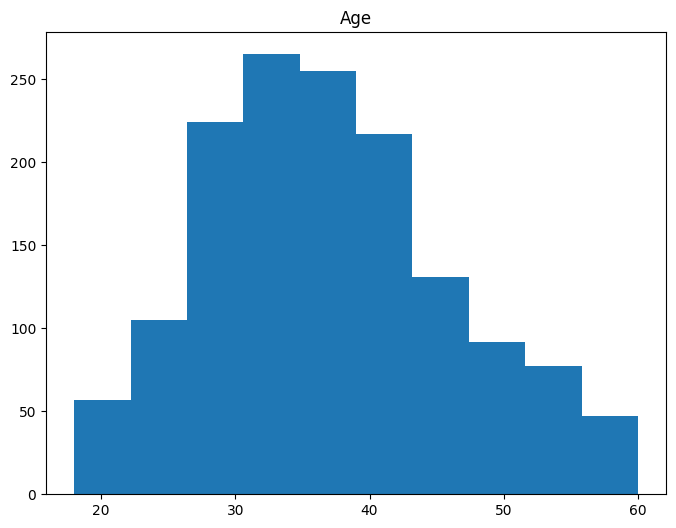

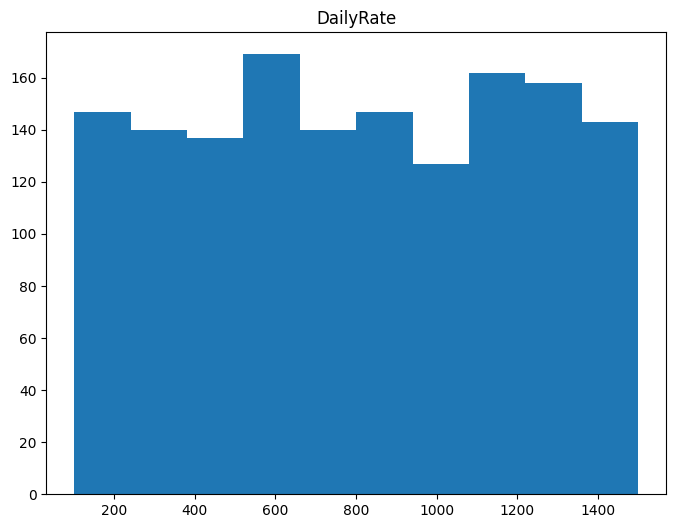

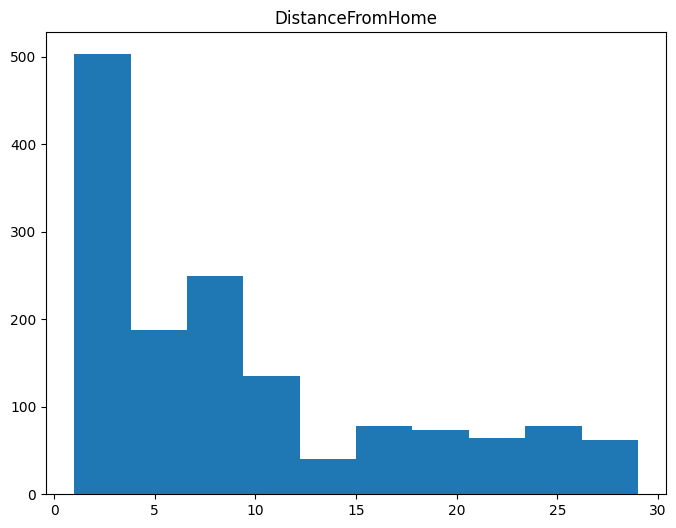

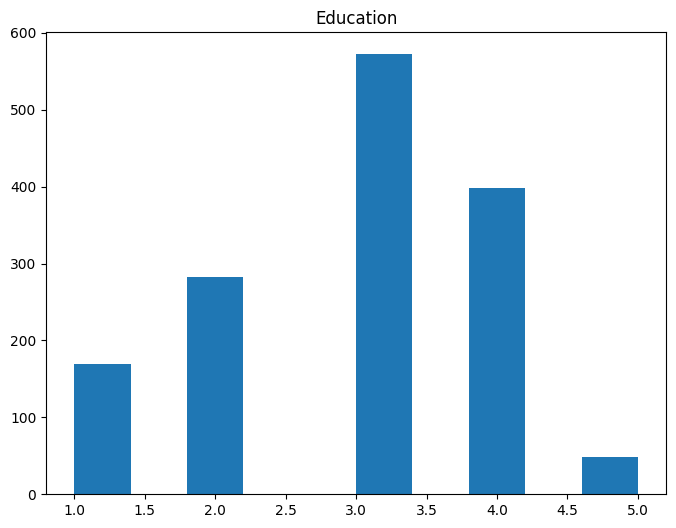

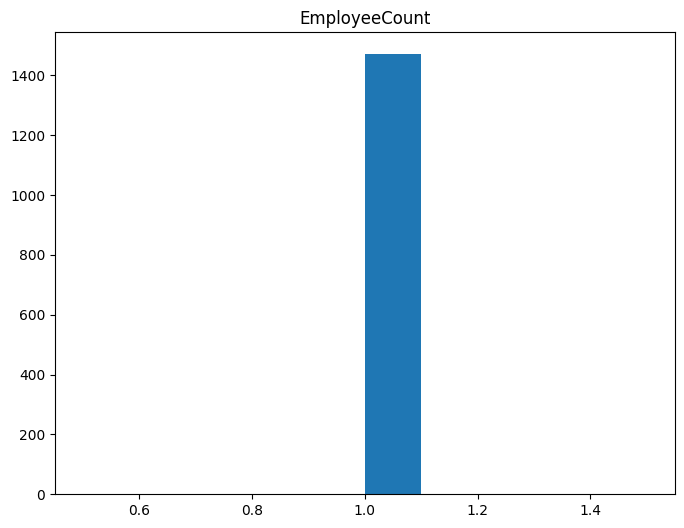

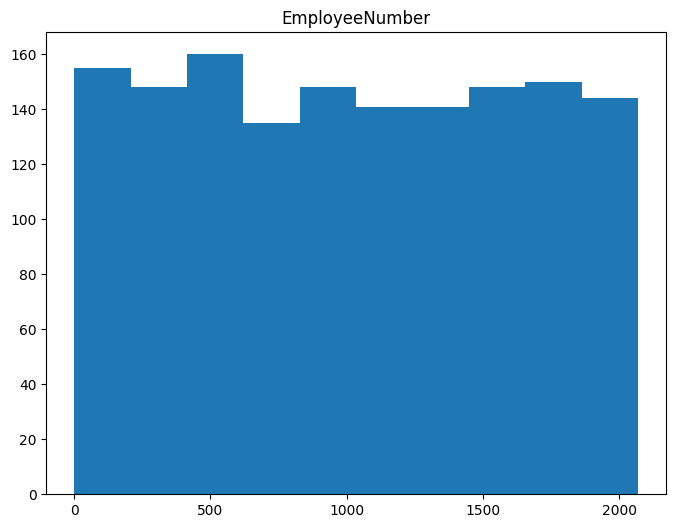

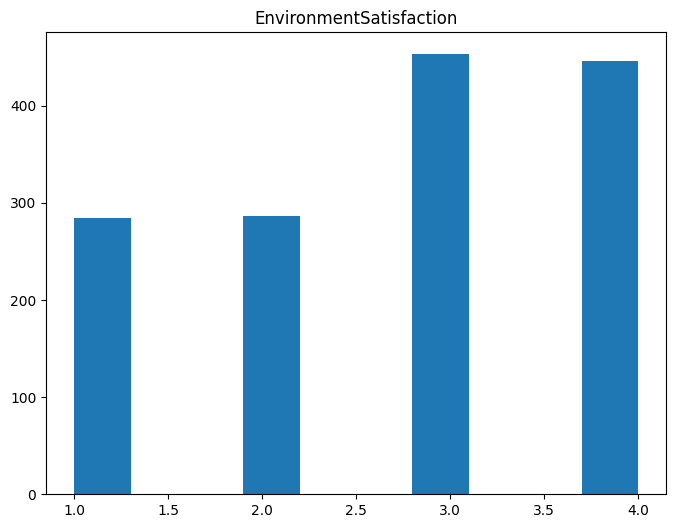

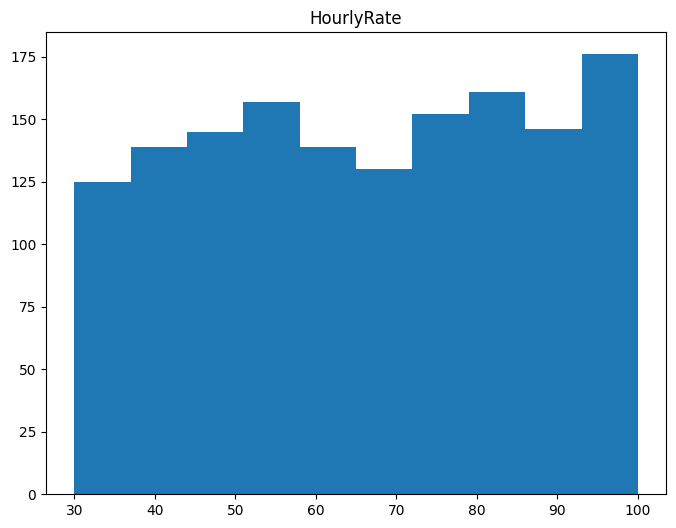

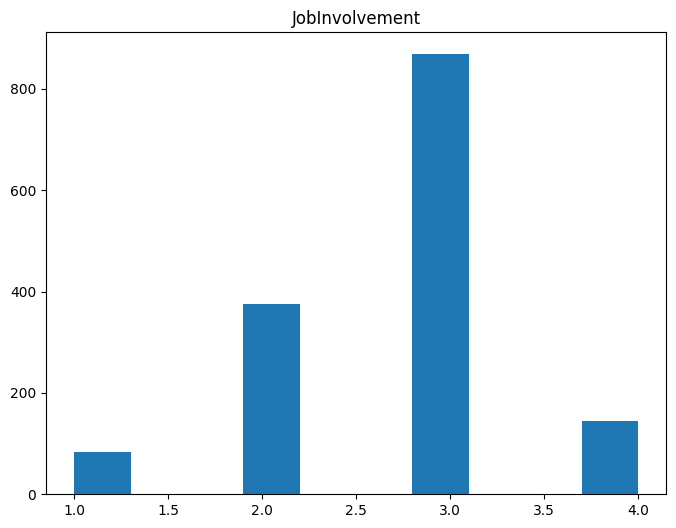

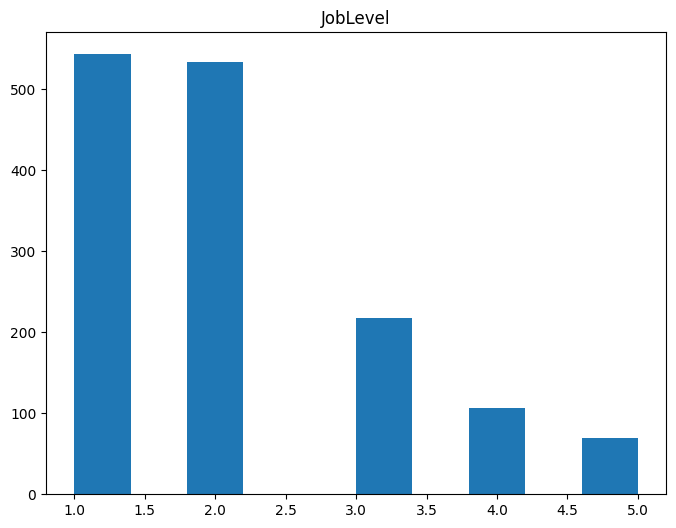

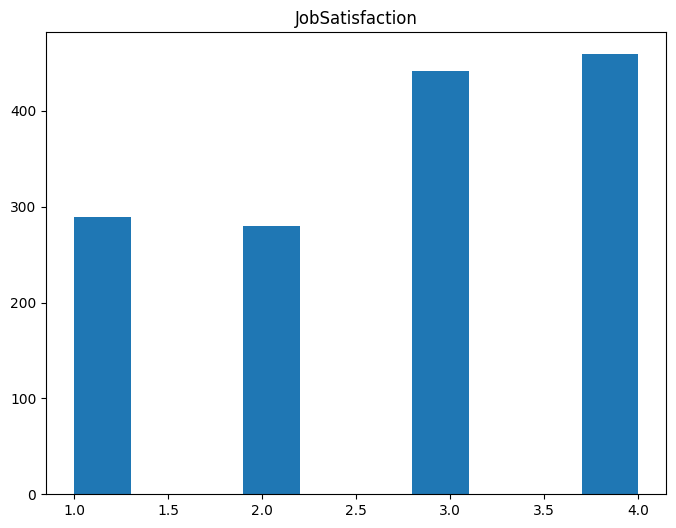

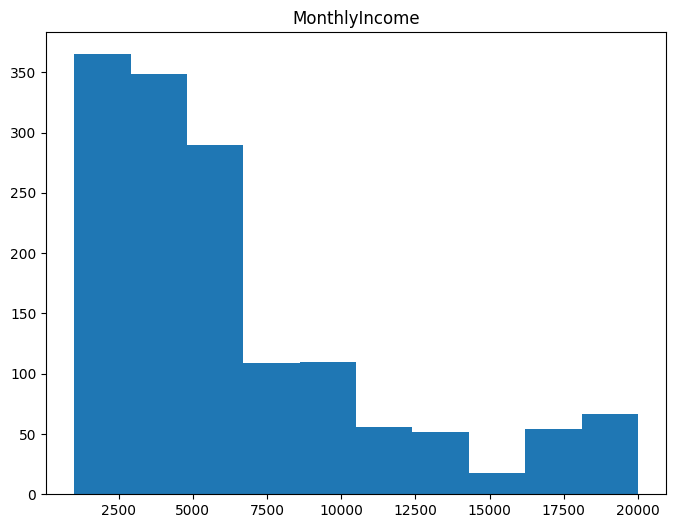

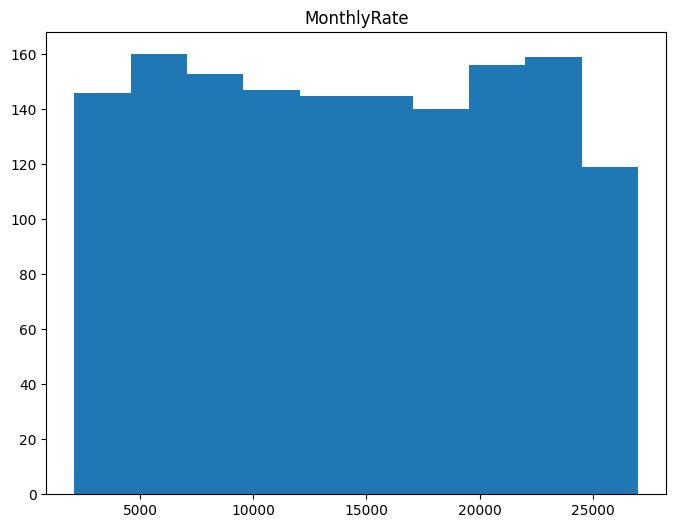

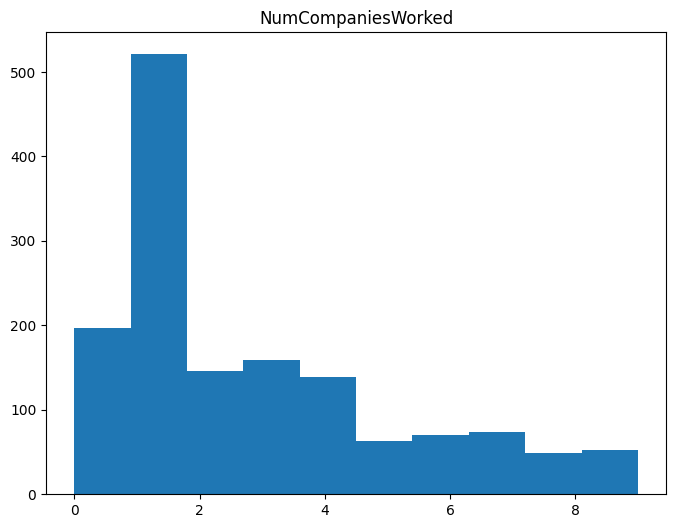

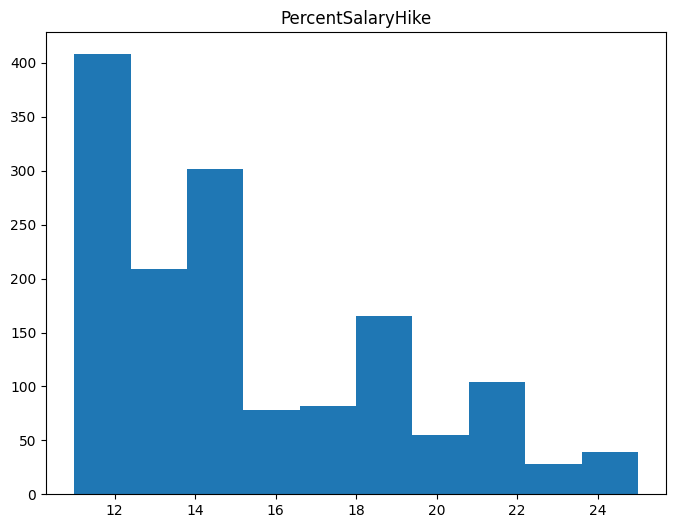

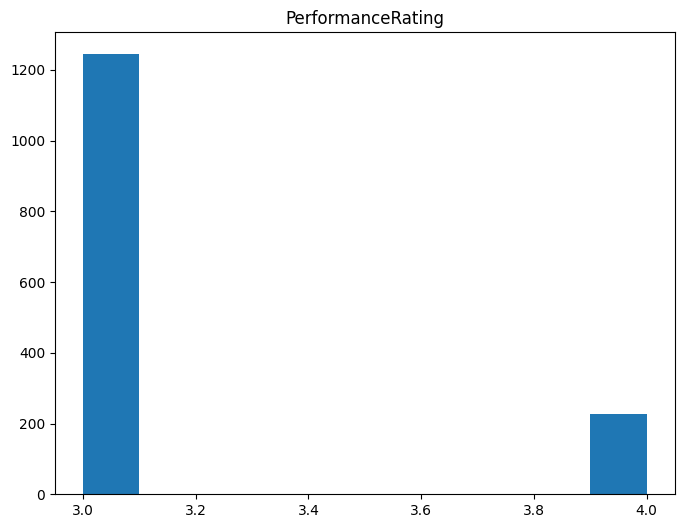

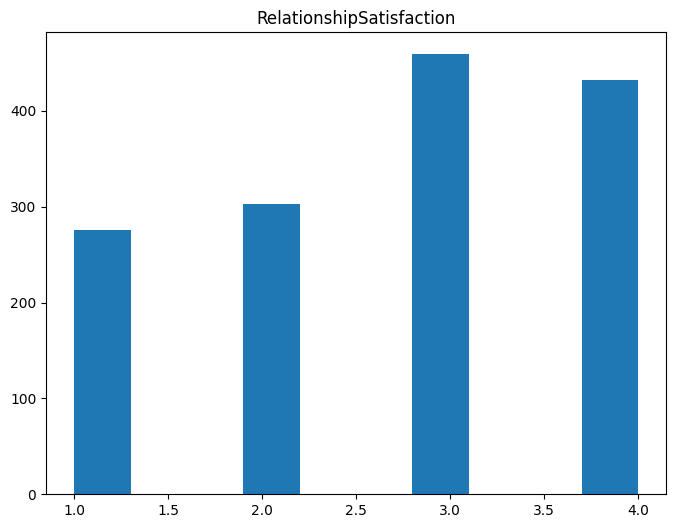

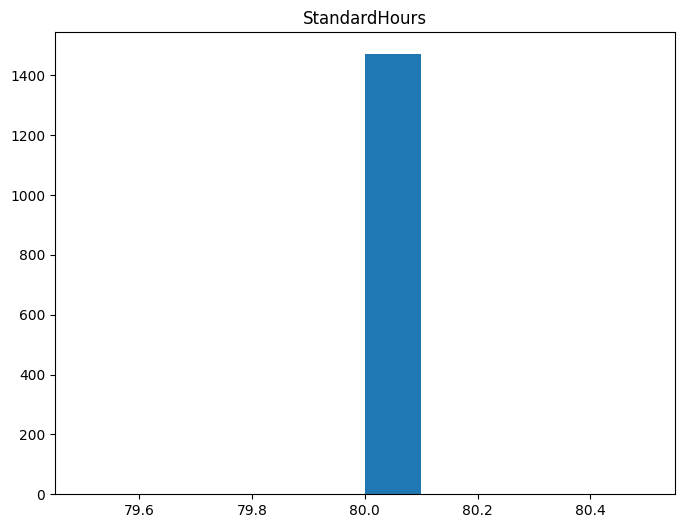

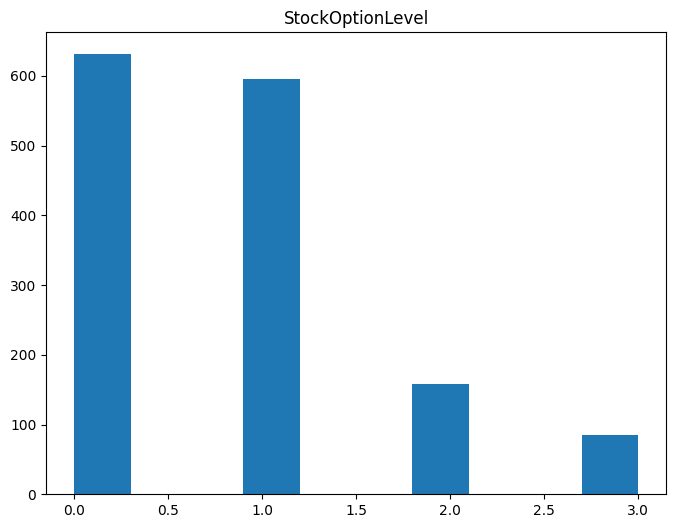

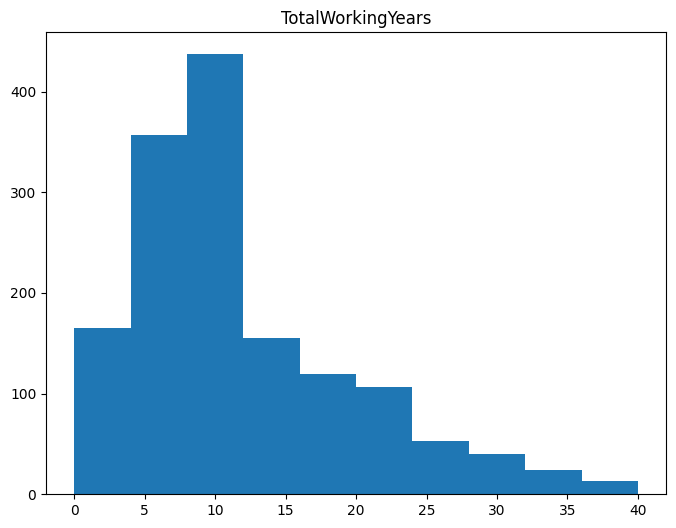

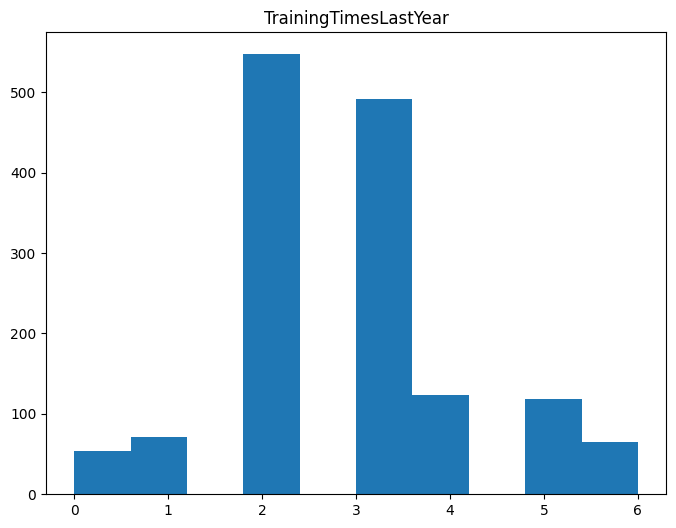

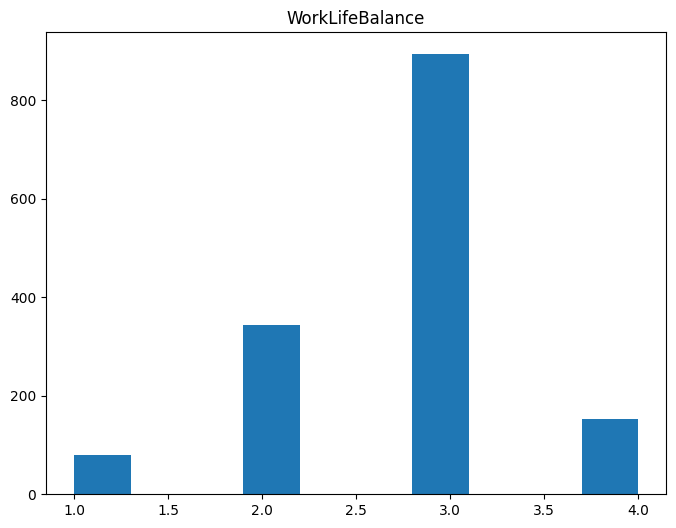

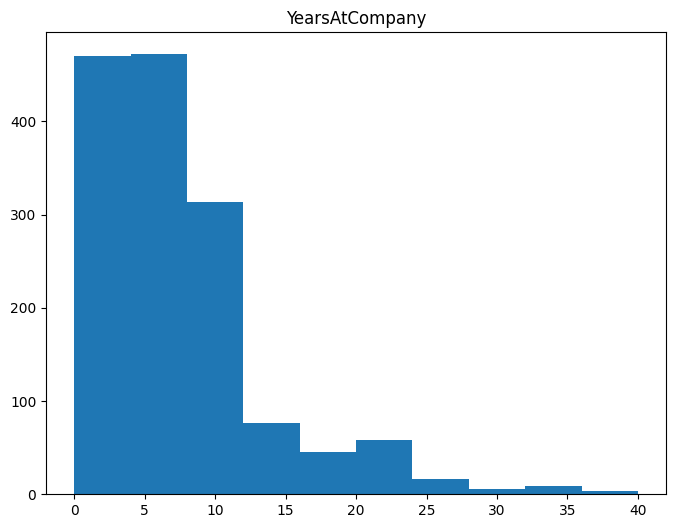

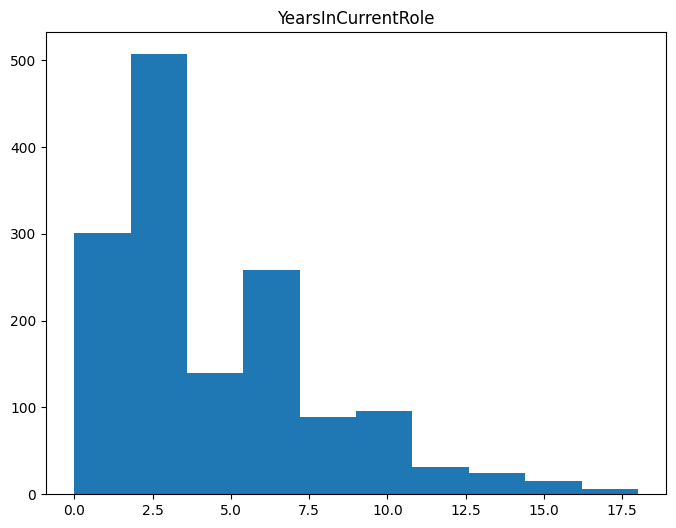

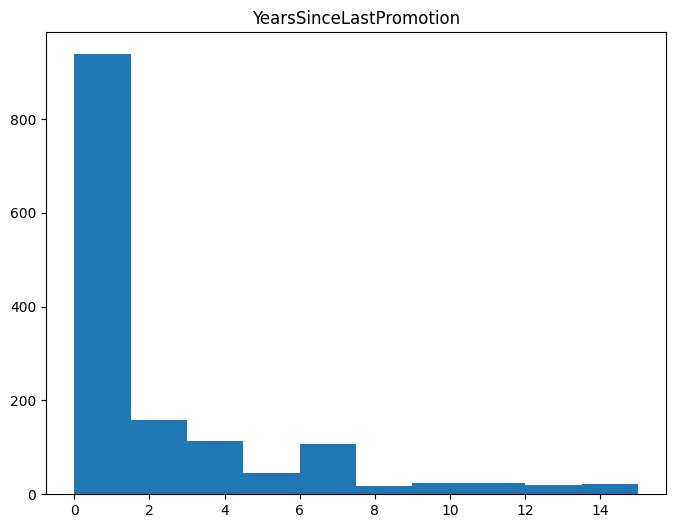

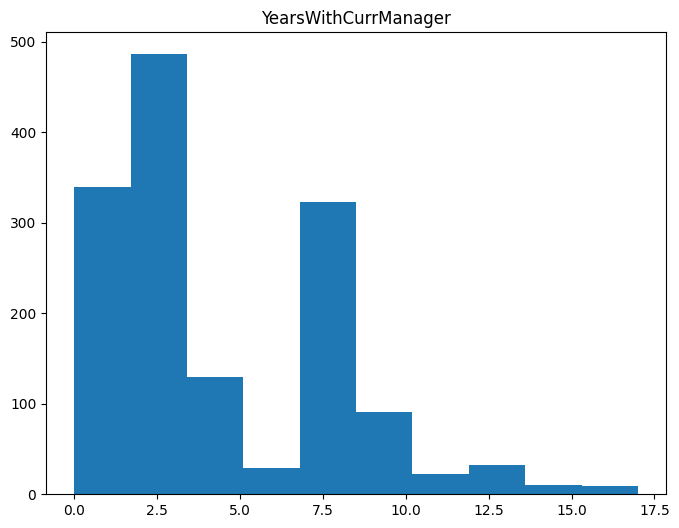

In [ ]:
# Display distribution of numeric columns
numeric_cols_clean= df.select_dtypes(include=np.number).columns.tolist()

# Plot histrograms of numeric variables
for col in numeric_cols_clean:
  plt.figure(figsize=(8,6))
  plt.hist(df[col])
  plt.title(col)
  plt.show()


## Data Cleaning , Encoding, Scaling and Split


**3. One- hot encoding and train-test split**

I am treating attrition as the binary target and one hot encoding all categrotical predictors.


In [ ]:
# Drop columns with no variance
df_clean=df.drop(['EmployeeCount', 'StandardHours', 'Over18'], axis=1)

X=df_clean.drop(columns=['Attrition'])
y=df_clean['Attrition']

# 2. Convert target to numeric (Yes=1, No=0)
y_numeric = y.map({'Yes': 1, 'No': 0})

# One hot encode categorical variables
X_encoded=pd.get_dummies(X, drop_first=True)

# Split into train/ test dataset
X_train, X_test, y_train, y_test= train_test_split(X_encoded, y_numeric,
                              test_size=0.3, random_state=42, stratify=y_numeric
)

# Identify numeric and boolean columns
numeric_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns
bool_cols = X_encoded.select_dtypes(include=['bool']).columns

# Scaling the numeric variables
scaler= StandardScaler()

X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
X_train_scaled_numeric = pd.DataFrame(X_train_scaled_numeric, columns=numeric_cols, index=X_train.index)

X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])
X_test_scaled_numeric = pd.DataFrame(X_test_scaled_numeric, columns=numeric_cols, index=X_test.index)

# Recombine scaled numeric + unscaled boolean columns
X_train_scaled = pd.concat([X_train_scaled_numeric, X_train[bool_cols]], axis=1)
X_test_scaled = pd.concat([X_test_scaled_numeric,  X_test[bool_cols]],  axis=1)



Target variable 'Attrition' is a string so we convert it into numeric values where 'Yes'=1 and 'No'=0. I split the dataset into 70% train and 30% test dataset. I scaled the numeric predictor variables using standard scalar. I encoded the categorical variables using one hot encoding then combined the encoded boolean values of character variables to form test and train datasets.

**4. Helper function to train and evaluate models**


In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, proba=True):
  """ Train a model, compute key metrics, and return a results dict."""
# Train the model
  model.fit(X_train, y_train)

# Get predictions on test set
  y_pred= model.predict(X_test)

# Get prediction scores for AUC
# If model has predic_proba, it uses probabilities, otherwise it uses decision functions. If
# neither is available, it falls back to the predicted class.
  if proba and hasattr(model, "predict_proba"):
    y_score= model.predict_proba(X_test)[:,1]
  else:
    y_score=(
        model.decision_function(X_test)
        if hasattr(model, "decision_function")
        else y_pred
    )
# Compute classification metrics
  acc=accuracy_score(y_test, y_pred)
  prec= precision_score(y_test, y_pred)
  rec= recall_score(y_test, y_pred)
  f1= f1_score(y_test, y_pred)
  try:

      auc=roc_auc_score(y_test, y_score)
  except Exception:
      auc=np.nan
# Computes confustion matrix
  cm= confusion_matrix(y_test, y_pred)

# Returns a dictionary of all results + the trained model
  results= {
      "model_name": name,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "f1_score": f1,
      "roc_auc": auc,
      "confusion_matrix": cm,
      "estimator": model,
  }
  return results

# Baseline Models

## Train All Models

In [ ]:
results=[]

# Logistic Regression
log_reg=LogisticRegression( max_iter=500, solver="lbfgs")
results.append(
    evaluate_model("Logistic Regression", log_reg, X_train_scaled, X_test_scaled, y_train, y_test)
)

# Decision Tree
dt= DecisionTreeClassifier(random_state=42, max_depth=5)
results.append (
    evaluate_model("Decision Tree", dt, X_train, X_test, y_train, y_test)
)

# Random Forest
rf=RandomForestClassifier( n_estimators=200, random_state=42, max_depth=None)
results.append(
    evaluate_model("Random Forest", rf, X_train, X_test, y_train, y_test)
)

# Gradient Boosting
gb= GradientBoostingClassifier( random_state=42)
results.append(
    evaluate_model("Gradient Boost", gb, X_train, X_test, y_train, y_test)
)

# Support Vector Machine (SVM)
svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
results.append(
    evaluate_model("SVM (RBF)", svm_clf, X_train_scaled, X_test_scaled, y_train, y_test)
)

# Neural Network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42,
)

results.append(
    evaluate_model("Neural Network (MLP)", mlp, X_train_scaled, X_test_scaled, y_train, y_test)
)

results_df=pd.DataFrame([
    {k:v for k,v in result.items() if k not in ["estimator","confusion_matrix"]}
    for result in results
])
results_df.sort_values("roc_auc", ascending=False)


,model_name,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.877551,0.717949,0.394366,0.509091,0.819718
4,SVM (RBF),0.868481,0.882353,0.211268,0.340909,0.799182
3,Gradient Boost,0.850340,0.580645,0.253521,0.352941,0.779901
2,Random Forest,0.834467,0.450000,0.126761,0.197802,0.764636
5,Neural Network (MLP),0.845805,0.526316,0.422535,0.468750,0.759155
1,Decision Tree,0.814059,0.387755,0.267606,0.316667,0.632166


ROC AUC score is a single number that summarizes the classifier's performance across all possible classification thresholds. A higher ROC AUC indicates better performance. A perfect model would have an AUC of 1, while a random model would have an AUC of 0.5.(https://www.evidentlyai.com/classification-metrics/explain-roc-curve)

Accuracy is the proportion of all classifications that were correct, whether positive or negative. A perfect model would have zero false positives and zero false negatives, and therefore an accuracy of 1. When the dataset is imbalanced, or where one kind of mistake (FN or FP) is more costly than the other, which is the case in most real-world applications, it's better to optimize for one of the other metrics instead.

The true positive rate (TPR), or the proportion of all actual positives that were classified correctly as positives, is also known as recall. A hypothetical perfect model would have zero false negatives and therefore a recall (TPR) of 1. In an imbalanced dataset where the number of actual positives is very low, recall is a more meaningful metric than accuracy because it measures the ability of the model to correctly identify all positive instances.

Precision is the proportion of all the model's positive classifications that are actually positive. A hypothetical perfect model would have zero false positives and therefore a precision of 1. Precision and recall often show an inverse relationship, where improving one of them worsens the other.

The F1 score is the harmonic mean (a kind of average) of precision and recall. The F1 score is the harmonic mean (a kind of average) of precision and recall. (https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall)

In HR attrition prediction, recall for the positive class is critical because:

-A false negative means an employee who is actually going to leave is predicted as staying,

-This is costly for the business (retention planning, succession planning, productivity loss).


### Interpretation of Model Evaluation

Logistic regression is best at general perdiction correctness which is shown by its highest roc_auc score. Suprprisingly, complex models like RF, GBM, MLP don't outperform it.
SVM has highest precision meaning that it has highest accuracy in predicting actual attrition.
NN has highest recall meaning that it is best at identifying attritions. Random forest has the lowest recall indicating that it misses many true attritions (positives).
Logistic regression achieves the best balance as shown by F1 score. It has second highest score for both precision and recall.
Based on the evaluation metrics, logistic regresison emerges as best at separting positive vs negative classes best across thresholds.
Lets see the model performance after tuning hyperparameters and adjusting class balances.

# Models with Tuned Hyperparameters

## Defining Hyper Parameter

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg_param_grid = {
    "class_weight": ["balanced", {0:1, 1:3},{0:1,1:5}], # Increases penalty for misclassifying minority class
    "solver": ["lbfgs", "liblinear"], # Works well with small/medium sized datasets
     "C": [0.1, 0.5,1], # Lower C implies more regularization and smoother boundaries
    "penalty":["l2"] # Stable for imbalanced data
}

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt_param_grid = {
    "class_weight": ["balanced"],
    "max_depth": [3,5,7],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

# 3. Random Forest
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "class_weight": ["balanced"], # Forces RF to consider minority
    "n_estimators": [200, 400], # More tree mean smoother boundaries
    "max_depth": [5,8, 12], # Prevents overfitting on majority class
    "min_samples_split": [2,5], # Controls complexity
    "min_samples_leaf": [1,2] # Useful for imbalance

}

# 4. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb_param_grid = {
    "learning_rate": [0.05, 0.1], # Controls the contribution of each tree, lower means better recall
    "n_estimators": [100,200], # More trees mean more complex patterns
    "max_depth": [3,5] # Shallow trees reduce overfitting

}

# 5. Support Vector Machine (SVM)
svm_clf = SVC(random_state=42, probability=True)
svm_clf_param_grid = {
    "class_weight": ["balanced"], # Forces SVM to care about false negatives
    "C": [1, 5], # Higher C= softer margin= increases recall
    "gamma": ["scale", "auto"], # Controls the influence of individual training samples
    "kernel": ["rbf"]
}

# 6. Neural Network (MLP)
mlp = MLPClassifier(random_state=42, max_iter=500)
mlp_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (31,16)], # Avoid large network= reduces overfitting
    "activation": ["relu", "tanh"], # Tests both
    "alpha": [0.0001, 0.001], # Better Regularization
    "learning_rate_init": [0.001,0.01] # Controls optimization smoothness

}

# Store models and their parameter grids in a dictionary
models_and_params = {
    "Logistic Regression": (log_reg, log_reg_param_grid),
    "Decision Tree": (dt, dt_param_grid),
    "Random Forest": (rf, rf_param_grid),
    "Gradient Boosting": (gb, gb_param_grid),
    "SVM": (svm_clf, svm_clf_param_grid),
    "Neural Network (MLP)": (mlp, mlp_param_grid),
}

print("Models and hyperparameter grids defined successfully")



Models and hyperparameter grids defined successfully


In gradient boosting, the learning rate and number of estimators are two of the most important hyperparameters because they work together to control model complexity, generalization and tendency to overfit/underfit. Learning rate controls how much each new tree contributes to correcting errors made by previous trees. Higher learning rate means faster learning, but it risks overfitting. Lower rates like 0.01 and 0.05 mean slower learning, more robust and stable model. While tuning the hyperparameter, I used lower learning rates so that the model learns slowly preventing overfitting.
Number of estimators is the number of boosting stages i.e. number of decision trees added sequentially. More trees mean better performance with low learning so it requires high computational power. Fewer trees mean faster training but high risk of underfitting. While tuning the hyperparameters, I am using ‘n_estimators’ 100 and 200.
In short, learning rate controls the contribution of each tree. Lower values improve generalization but need more trees. Number of estimators controls how many weak learners are added. More trees improve accuracy but risk overfitting. There is inverse relationship between the two. My tuned model is using lower learning rate with relatively fewer trees.


## Perform hyperparameter tuning using GridSearchCV

In [ ]:
tuned_results=[]
best_estimators={}

for name, (model, param_grid) in models_and_params.items():
    print (f"Tuining {name}...")

    # Determing which data to use based on the model type
    if name in ["Logistic Regression","SVM", "Neural Network (MLP)"]:
        X_train_tuned=X_train_scaled
    else:
        X_train_tuned=X_train

    grid_search=GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="roc_auc", # Using ROC AUC as the primary scoring metric
        cv=5,
        verbose=0, # Set to 0 to supress output during fitting
        n_jobs=-1 # Use all available CPU cores
    )
    grid_search.fit(X_train_tuned, y_train)

    best_estimator=grid_search.best_estimator_
    best_score=grid_search.best_score_
    best_params=grid_search.best_params_

    best_estimators[name]=best_estimator

    tuned_results.append({
        "model": name,
        "best_score": best_score,
        "best_params": best_params,
        "estimator": best_estimator
    })
print ("Hyperparameter tuning completed for all models.")

Tuining Logistic Regression...
Tuining Decision Tree...
Tuining Random Forest...
Tuining Gradient Boosting...
Tuining SVM...
Tuining Neural Network (MLP)...
Hyperparameter tuning completed for all models.


In [ ]:
tuned_results

[{'model': 'Logistic Regression',
  'best_score': np.float64(0.8215129637869886),
  'best_params': {'C': 0.5,
   'class_weight': {0: 1, 1: 3},
   'penalty': 'l2',
   'solver': 'lbfgs'},
  'estimator': LogisticRegression(C=0.5, class_weight={0: 1, 1: 3}, max_iter=1000,
                     random_state=42)},
 {'model': 'Decision Tree',
  'best_score': np.float64(0.6936029798151525),
  'best_params': {'class_weight': 'balanced',
   'max_depth': 3,
   'min_samples_leaf': 4,
   'min_samples_split': 2},
  'estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=4,
                         random_state=42)},
 {'model': 'Random Forest',
  'best_score': np.float64(0.8052295029879382),
  'best_params': {'class_weight': 'balanced',
   'max_depth': 12,
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'n_estimators': 200},
  'estimator': RandomForestClassifier(class_weight='balanced', max_depth=12,
                         min_samples_split=5, n_estimators=

In [ ]:
tuned_model_evaluation_results = []

for name, estimator in best_estimators.items():
    print(f"Evaluating tuned {name}...")

    # Determine which data to use for evaluation based on the model type
    if name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]:
        X_train_input_for_evaluate = X_train_scaled
        X_test_input_for_evaluate = X_test_scaled
    else:
        X_train_input_for_evaluate = X_train
        X_test_input_for_evaluate = X_test

    proba_support = hasattr(estimator, "predict_proba")

    evaluation_result = evaluate_model(
        name,
        estimator,
        X_train_input_for_evaluate, # Pass the correct training data
        X_test_input_for_evaluate,  # Pass the correct test data
        y_train,
        y_test,
        proba=proba_support
    )
    tuned_model_evaluation_results.append(evaluation_result)

tuned_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "estimator"]}
    for r in tuned_model_evaluation_results
])
display(tuned_results_df.sort_values("roc_auc", ascending=False))

print("Evaluation of tuned models completed.")

Evaluating tuned Logistic Regression...
Evaluating tuned Decision Tree...
Evaluating tuned Random Forest...
Evaluating tuned Gradient Boosting...
Evaluating tuned SVM...
Evaluating tuned Neural Network (MLP)...


,model_name,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.843537,0.511905,0.605634,0.554839,0.817472
5,Neural Network (MLP),0.875283,0.690476,0.408451,0.513274,0.814884
4,SVM,0.820862,0.459184,0.633803,0.532544,0.806700
3,Gradient Boosting,0.859410,0.636364,0.295775,0.403846,0.786068
2,Random Forest,0.836735,0.476190,0.140845,0.217391,0.768481
1,Decision Tree,0.734694,0.320312,0.577465,0.412060,0.695546


Evaluation of tuned models completed.


Logistic regression continues to deliver the best ROC_AUC score meaning that it still ranks highest in distinguishing attrition vs non-attrition. Although ROC_AOC score decreased slightly from  0.8197 to 0.8175, recall improved dramatically indicating that the model is now better at indentifying actual leavers. F! score also increases, meaning overall predictive usefullness improved. MLP shows major improvement in ROC_AOC score moving from near bottom (0.759) to second best (0.815) after tuining. F1 improved meaning model gets balanced precision-recall performances however, recall slightly decreased from 0.4225 to 0.4085. SVM delivers the strongest improvement in recall from 0.2113 to 0.6338 (highest among all models) making it valuable when preventing false negatives is essential. Gradient boosting and decision tree has slight improvements in ROC_AOC scores but random forest's score remains flat. Decision tree sees substantial improvement in recall but accuracy drops significantly with moderate AOC_ROC. Random forest's recall continues to struggle capturing minority class even with balanced weight.

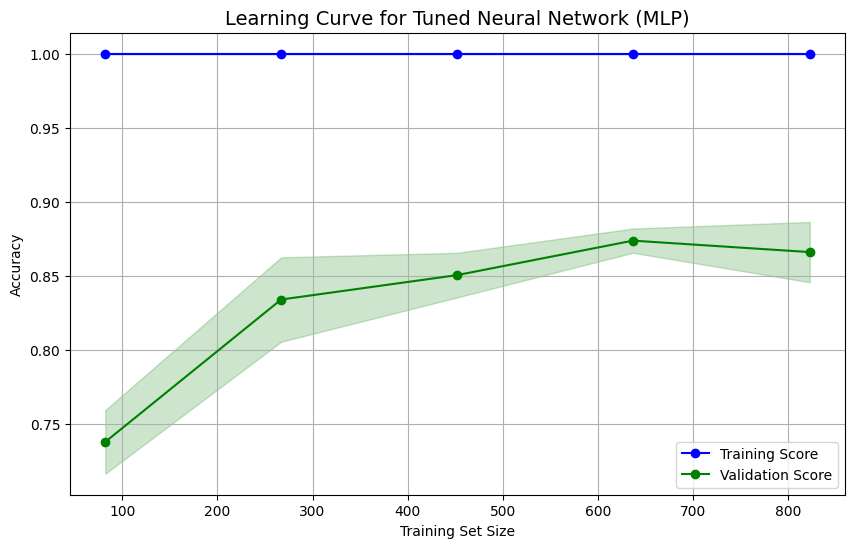

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Get the tuned MLP estimator
tuned_mlp = MLPClassifier(activation='tanh', hidden_layer_sizes=(64,), max_iter=500,
                random_state=42)

# Create a pipeline that includes scaling and the tuned MLP model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', tuned_mlp)
])

# Generate learning curve data using the pipeline
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline, # Use the pipeline as the estimator
    X=X_train_scaled,          # Use the unscaled, encoded features
    y=y_train,          # Use the numeric target labels
    cv=5,                 # 5-fold cross validation
    scoring="accuracy",
    n_jobs=-1,            # Use all available CPU cores
    train_sizes=np.linspace(0.1, 1.0, 5) # Use 5 different training set sizes
)

# Compute means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')

# Error bands
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2, color='blue')

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2, color='green')

plt.title("Learning Curve for Tuned Neural Network (MLP)", fontsize=14)
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Interpretation of the Learning Curve

A learning curve helps us understand how a model's performance changes with the amount of training data. It plots the model's accuracy (or other metric) on both the training set and a separate validation set as the size of the training data increases.

**Key Observations from my MLP Learning Curve:**

1.  **High Training Score (Blue Line):** The training accuracy consistently stays at 1.0 (or very close to it) across all training set sizes. This indicates that my Neural Network is capable of learning the training data perfectly.

2.  **Lower Validation Score (Green Line):** The validation accuracy starts lower than the training accuracy and shows significant improvement as the training data increases, eventually leveling off around 0.86-0.87. However, there's still a noticeable gap between the training and validation scores.

3.  **The Gap:** The substantial difference between the training score (perfect 1.0) and the validation score (around 0.86-0.87) suggests that the model is **overfitting** the training data. This means it has learned the training examples, including noise and specific patterns, too well, making it less effective at generalizing to new, unseen data.

4.  **Plateauing Validation Curve:** The validation curve tends to flatten out, which implies that adding more training data *beyond a certain point* might not lead to significant improvements in the model's generalization performance. The model has likely reached its capacity to learn from the existing data distribution.

**In Summary:**

The Tuned Neural Network (MLP) appears to be **overfitting**. While it's excellent at memorizing the training data, it struggles to perform as well on new, unseen examples. To address this, I can consider:

*   **Regularization techniques:** Such as L1, L2 regularization, or dropout layers within the neural network to prevent it from relying too heavily on specific features.
*   **Simplifying the model architecture:** Reducing the number of hidden layers or neurons in the existing layers might help.
*   **Cross-validation:** Using techniques like k-fold cross-validation during training can give a more robust estimate of model performance and help in tuning hyperparameters that reduce overfitting.

# Models with ADASYN to Balance Class

In [ ]:
!pip install imbalanced-learn

Since our dataset has imbalanced class, we use ADASYN to make the classes balanced. ADASYN oversample minority attrition cases (class=1) producing synthetic examples near difficult regions of boundary.

## Apply ADASYN to Training Data

In [ ]:
from imblearn.over_sampling import ADASYN

# 2. Instantiate ADASYN
adasyn_sampler = ADASYN(random_state=42)

# 3. Apply ADASYN to original training data
X_train_adasyn, y_train_adasyn = adasyn_sampler.fit_resample(X_train, y_train)
print(f"Original training data shape: {X_train.shape}, {y_train.shape}")
print(f"ADASYN resampled original training data shape: {X_train_adasyn.shape}, {y_train_adasyn.shape}")
print(f"Class distribution after ADASYN (original):\n{y_train_adasyn.value_counts()}")

# 4. Apply ADASYN to scaled training data
X_train_scaled_adasyn, y_train_scaled_adasyn = adasyn_sampler.fit_resample(X_train_scaled, y_train)
print(f"\nScaled training data shape: {X_train_scaled.shape}, {y_train.shape}")
print(f"ADASYN resampled scaled training data shape: {X_train_scaled_adasyn.shape}, {y_train_scaled_adasyn.shape}")
print(f"Class distribution after ADASYN (scaled):\n{y_train_scaled_adasyn.value_counts()}")

Original training data shape: (1029, 45), (1029,)
ADASYN resampled original training data shape: (1677, 45), (1677,)
Class distribution after ADASYN (original):
Attrition
0    863
1    814
Name: count, dtype: int64

Scaled training data shape: (1029, 45), (1029,)
ADASYN resampled scaled training data shape: (1670, 45), (1670,)
Class distribution after ADASYN (scaled):
Attrition
0    863
1    807
Name: count, dtype: int64


## Evaluating Tuned Models with ADASYN

In [ ]:
adasyn_tuned_model_evaluation_results = []

for name, estimator in best_estimators.items():
    print(f"Evaluating tuned {name} with ADASYN data...")

    # Determine which ADASYN-resampled training data to use based on the model type
    if name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]:
        X_train_adasyn_data = X_train_scaled_adasyn
        y_train_adasyn_data = y_train_scaled_adasyn
    else:
        X_train_adasyn_data = X_train_adasyn
        y_train_adasyn_data = y_train_adasyn

    # Check if the estimator has a predict_proba method for ROC AUC
    proba_support = hasattr(estimator, "predict_proba")

    # Call the evaluate_model function
    evaluation_result = evaluate_model(
        name,
        estimator,
        X_train_adasyn_data,
        X_test_scaled if name in ["Logistic Regression", "SVM", "Neural Network (MLP)"] else X_test,
        y_train_adasyn_data,
        y_test,
        proba=proba_support
    )
    adasyn_tuned_model_evaluation_results.append(evaluation_result)

adasyn_tuned_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "estimator"]}
    for r in adasyn_tuned_model_evaluation_results
])
display(adasyn_tuned_results_df.sort_values("roc_auc", ascending=False))

print("Evaluation of tuned models with ADASYN data completed.")

Evaluating tuned Logistic Regression with ADASYN data...
Evaluating tuned Decision Tree with ADASYN data...
Evaluating tuned Random Forest with ADASYN data...
Evaluating tuned Gradient Boosting with ADASYN data...
Evaluating tuned SVM with ADASYN data...
Evaluating tuned Neural Network (MLP) with ADASYN data...


,model_name,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.777778,0.390244,0.676056,0.494845,0.816483
4,SVM,0.863946,0.603774,0.450704,0.516129,0.816140
5,Neural Network (MLP),0.891156,0.780488,0.450704,0.571429,0.810811
3,Gradient Boosting,0.834467,0.479167,0.323944,0.386555,0.758432
2,Random Forest,0.834467,0.476190,0.281690,0.353982,0.731785
1,Decision Tree,0.689342,0.253731,0.478873,0.331707,0.632299


Evaluation of tuned models with ADASYN data completed.


## Compare Performance with and without ADASYN

In [ ]:
tuned_results_df_copy = tuned_results_df.copy()
tuned_results_df_copy["Sampling"] = "No ADASYN"

adasyn_tuned_results_df_copy = adasyn_tuned_results_df.copy()
adasyn_tuned_results_df_copy["Sampling"] = "ADASYN"

comparison_df = pd.concat([tuned_results_df_copy, adasyn_tuned_results_df_copy], ignore_index=True)

# Sort for better readability, e.g., by model and then by sampling method
comparison_df_sorted = comparison_df.sort_values(by=["model_name", "Sampling"])
display(comparison_df_sorted)

,model_name,accuracy,precision,recall,f1_score,roc_auc,Sampling
7,Decision Tree,0.689342,0.253731,0.478873,0.331707,0.632299,ADASYN
1,Decision Tree,0.734694,0.320312,0.577465,0.412060,0.695546,No ADASYN
9,Gradient Boosting,0.834467,0.479167,0.323944,0.386555,0.758432,ADASYN
3,Gradient Boosting,0.859410,0.636364,0.295775,0.403846,0.786068,No ADASYN
6,Logistic Regression,0.777778,0.390244,0.676056,0.494845,0.816483,ADASYN
0,Logistic Regression,0.843537,0.511905,0.605634,0.554839,0.817472,No ADASYN
11,Neural Network (MLP),0.891156,0.780488,0.450704,0.571429,0.810811,ADASYN
5,Neural Network (MLP),0.875283,0.690476,0.408451,0.513274,0.814884,No ADASYN
8,Random Forest,0.834467,0.476190,0.281690,0.353982,0.731785,ADASYN
2,Random Forest,0.836735,0.476190,0.140845,0.217391,0.768481,No ADASYN


Logistic regression continues to have the highest ROC_AOC score weven with ADASYN. Recall had moderate improvement from 0.6056 to 0.6761 but f1 score and ROC_AOC scores both observed slight decrease. ADASYN is preferred if HR propritizing maximizing recall but if it prioritizes balance, interpretability and stability, no ADASYN is suitable.
 SVM has the second highest ROC_AOC score at 0.8161 but with reduced recall and f1 score. MLP observed slight reduction in AOC_ROC score but improvement in accuracy, precision, recall and f1 score. Recall for gradient boosting slightly improved from 0.2958 to 0.38655 but all other metrics saw decline meaning that the model did not react well to synthetic samples. Random forest saw Recall and f1 score to have slight improvement but all other metrics declined. ADASYN harmed performances across all metrics for decision trees indicating that it is extremely sensitive to synthetic data becoming unstable.

Human resource departments don't want to wrongly predict leavers as stayers beacuse it is more expensive than wrongly predicting stayers as leavers. False negatative results in loss of talent and expertise, increased recruitment cost, productivity loss and loss of institutional knowledge. So, the human resource department will prioritize recall, f1-score and ROC_AUC scores.
Logistic regression with ADASYN has the highest recall indicating that it is best at predicting actual leavers. However, it has reduced f1 score and ROC_AOC that measures balance of precision and recall, and how well model distinguishes respectively.
Considering the best overall performance in recall, f1 and ROC_AOC, models with tuned parameters performs the best so we will use the model with tuned parameters for feature selection and further recommendation.

# Feature Importance Analysis

## Feature Importance Logistic Regression


In [ ]:
# Extract the logistic regression model from the tuned_results
log_reg_model = tuned_results[0]['estimator']

# Get feature names from the training data
features = X_train_scaled.columns

# Get coefficients from the trained model (these represent feature importance for logistic regression)
coefficients = log_reg_model.coef_[0]

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': coefficients})

# Calculate absolute importance to sort features regardless of the direction of their impact
feature_importance_df['Absolute_Importance'] = abs(feature_importance_df['Importance'])

# Sort features by absolute importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False)

# Get the names of the top 10 most important features
top_10_features = feature_importance_df.head(10)['Feature'].tolist()

# Filter the feature_importance_df for the top 10 features
selected_features_df = feature_importance_df[feature_importance_df["Feature"].isin(top_10_features)]

selected_features_df

,Feature,Importance,Absolute_Importance
34,JobRole_Human Resources,2.622919,2.622919
24,BusinessTravel_Travel_Frequently,2.276724,2.276724
35,JobRole_Laboratory Technician,2.191142,2.191142
41,JobRole_Sales Representative,1.948396,1.948396
43,MaritalStatus_Single,1.927013,1.927013
44,OverTime_Yes,1.900045,1.900045
25,BusinessTravel_Travel_Rarely,1.552303,1.552303
32,EducationField_Technical Degree,1.448323,1.448323
30,EducationField_Medical,1.369136,1.369136
40,JobRole_Sales Executive,1.329082,1.329082


/tmp/ipython-input-573267556.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Importance', y='Feature', data=selected_features_df, palette='viridis')


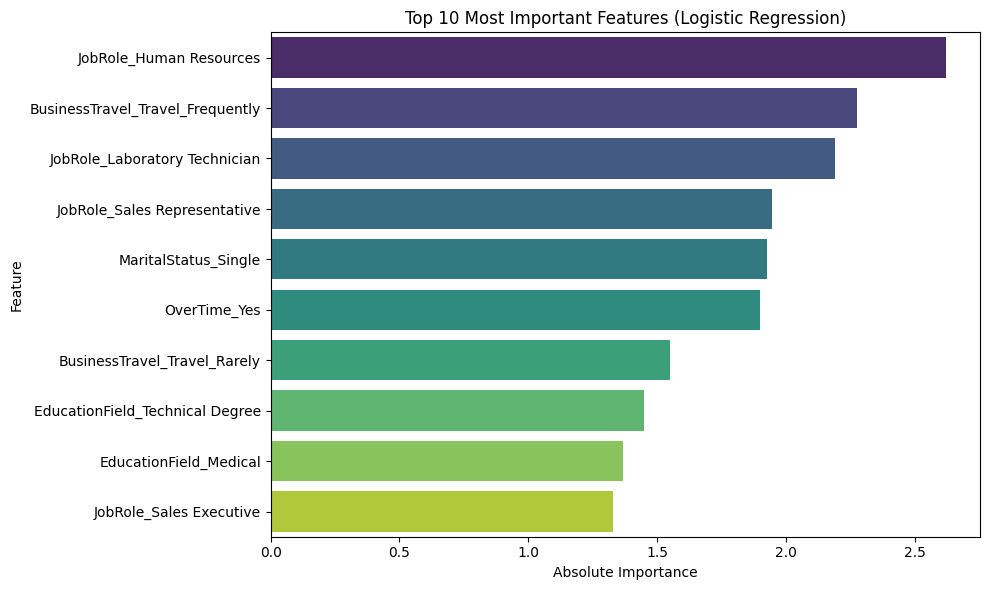

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the selected features by importance for better visualization
selected_features_df = selected_features_df.sort_values(by='Absolute_Importance', ascending=False)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Absolute_Importance', y='Feature', data=selected_features_df, palette='viridis')
plt.xlabel('Absolute Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features (Logistic Regression)')
plt.tight_layout()
plt.show()

The plot demonstrates top 10 variables that attribute to employees leaving a company. Positve values indicate that the likelihood of attrition increases with the increase in variable values. Larger absolute values indicate stronger influences.

The top variable influencing attrition is whether employee belong to human resource role. Employees in human resource roles are significantly more likely to attrite compared to other job roles. This also point towards high stress, internal conflicts and job market demand push that HR employee face which lead them to quit.

Second factor influencing attrition is travel requirement. Employee who travel frequently face burnouts, fatigue and work life-imbalance which is why they are more likely to leave.

Employees working as labroratory technicians and sales representatives also face higher attrition likelihood potentially due to repitative nature without upward mobility for the former and high pressured competitive environement for the later.

Single employees being more mobile are placed at fifth significant variable influencing attrition.

Employees who travel occassionally also have elevated attrition compared to those who don't travel at all.

Employees with technical degree have higher market demand potentially making it easy to find alternative job opportunities which is why it ranks eight in factors influencing attrition. Similarly, employee with medical degree ranks nineth potentially due to availabiliy of job alternatives or burnouts.

Streesfull environment, performance pressures and moblity may contribute to sales executives as tenth most important factor contributing to attrition.

Overall, we can see that employees with travel requirements, technical or sales related job roles, technical education, overtime requirement and convenince in mobility are more likely to leave organizations.

## Feature Importance Tree Models

In [ ]:
# Identofy the top 10 feature of gradient boosting based on model after hypertuning



,Feature,Importance,Model
16,StockOptionLevel,0.437567,Decision Tree
19,WorkLifeBalance,0.164033,Decision Tree
8,JobLevel,0.143258,Decision Tree
16,StockOptionLevel,0.121204,Gradient Boosting
9,JobSatisfaction,0.111626,Decision Tree
23,YearsWithCurrManager,0.092048,Decision Tree
42,MaritalStatus_Married,0.082740,Gradient Boosting
16,StockOptionLevel,0.067609,Random Forest
26,Department_Research & Development,0.064201,Gradient Boosting
42,MaritalStatus_Married,0.055332,Random Forest


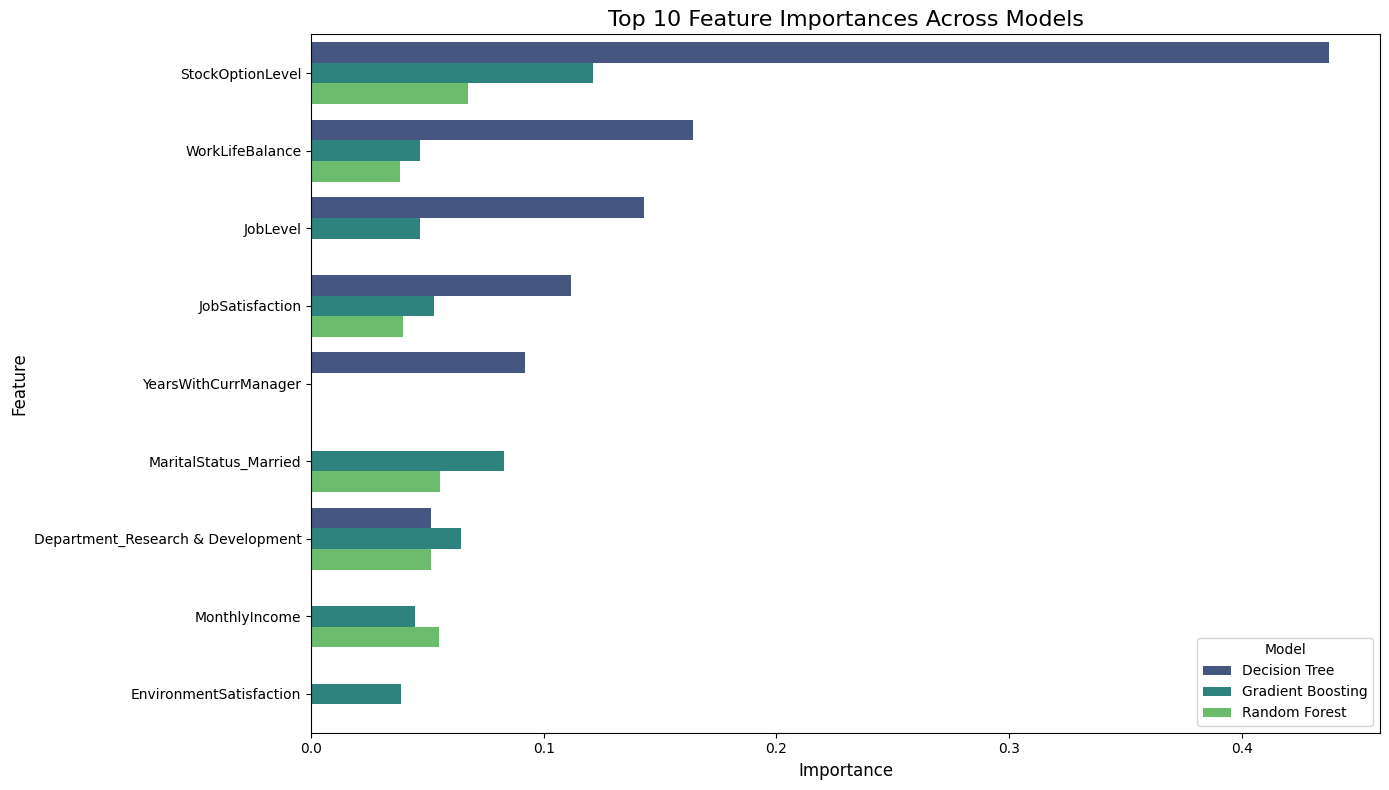

Feature importance analysis completed.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = []

# Get the feature names from the X_train_new_fe DataFrame
feature_names = X_train.columns.tolist()

for name, estimator in best_estimators.items():
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        if hasattr(estimator, 'feature_importances_'):
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': estimator.feature_importances_,
                'Model': name
            })
            feature_importances.append(importance_df)

if feature_importances:
    all_feature_importances = pd.concat(feature_importances)
    display(all_feature_importances.sort_values(by='Importance', ascending=False).head(20))

    # Visualize feature importances
    plt.figure(figsize=(14, 8))
    sns.barplot(x='Importance', y='Feature', hue='Model', data=all_feature_importances.sort_values(by='Importance', ascending=False).head(20), palette='viridis')
    plt.title('Top 10 Feature Importances Across Models', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No tree-based models found with feature_importances_ attribute.")

print("Feature importance analysis completed.")

Feature importance in tree-based models represents how each feature reduces uncertainty while making splits. Higher values indicate that models rely more on that feature for prediction. Stock option is dominant feature across all tree models while being the most influential variable in decision tree explaining 44% of decision structure. Work life balance and job satisfaction repeatedly follow stock options in all three models implying that poor work life balance, lower job satisfaction contributes significantly to attrition. The largest department research and development shows distinct attrition patterns like because it might have different workload or managerial dynamics. Comparison also identified demographic features like marital status influencing splits in gradient boosting and random forest. Job level, monthly income, environmental satisfaction and years with current managers were also identified as important features.
Overall, tree-based models illustrated how financial incentives like stock options and monthly income have high retention power. It also highlighted non-financial drivers like marital status, department and employee experience drivers that influence attrition.


# ROC Curve of Top Three Models

## ROC All Models- Tuned

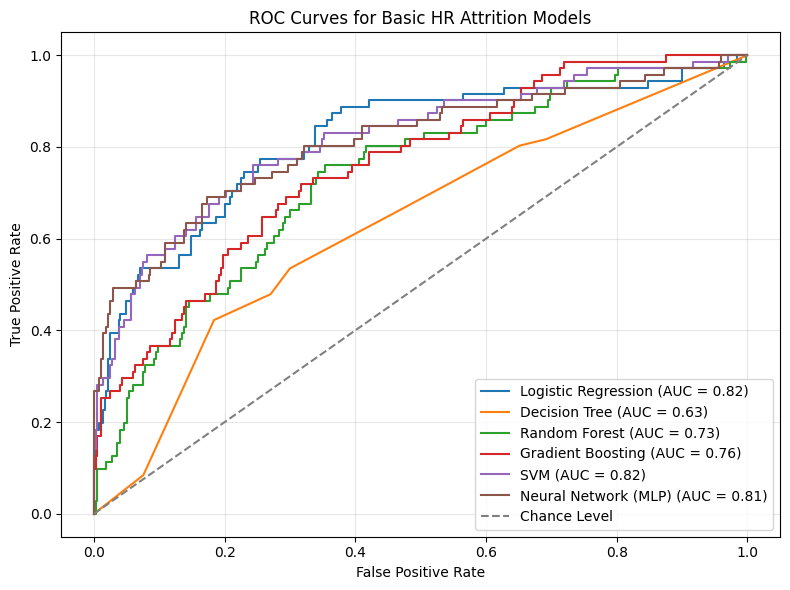

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score # Import necessary functions

plt.figure(figsize=(8, 6))

for r in tuned_results: # Iterate over 'results' for basic models
    name = r["model"]
    model = r["estimator"]

    # Determine which test data to use (scaled or unscaled) based on model type
    use_scaled = name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]
    X_test_input = X_test_scaled if use_scaled else X_test

    # Generate prediction scores (y_score for ROC AUC)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_input)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_input)
    else:
        print(f"Skipping {name}: Model does not support predict_proba or decision_function.")
        continue # Skip this model if scores cannot be obtained

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    # Plot ROC with AUC in legend
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Chance line (diagonal)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance Level")

plt.title("ROC Curves for Basic HR Attrition Models") # Adjusted title for clarity
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## ROC Curve of Top Three Models- Tuned Model

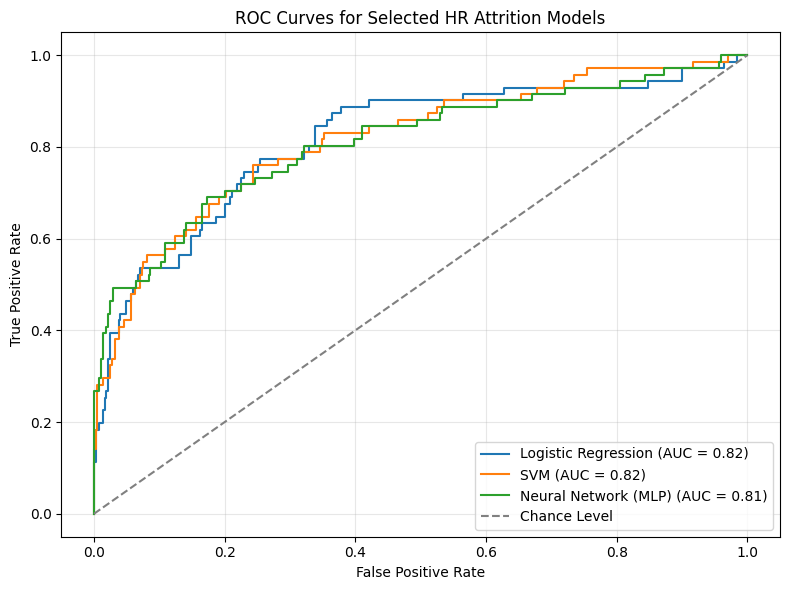

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Models to plot
selected_models = ["Logistic Regression", "SVM", "Neural Network (MLP)"]

plt.figure(figsize=(8, 6))

for r in tuned_results:
    name = r["model"]
    model = r["estimator"]

    # Only include selected models
    if name not in selected_models:
        continue

    # Determine if the model requires scaled test data
    use_scaled = name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]
    X_test_input = X_test_scaled if use_scaled else X_test

    # Generate prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_input)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_input)
    else:
        print(f"Skipping {name}: cannot compute probability scores.")
        continue

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    # Plot ROC with AUC in legend
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Chance line
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance Level")

plt.title("ROC Curves for Selected HR Attrition Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ROC curve is a graphical plot that shows tradeoff between sensitivity and false positive rate, helping us visualize how well a model distinguished between attrition and non-attrition. The ROC analysis demonstrates that Logistic Regression, SVM, and the Neural Network (MLP) deliver almost identical classification performance, with AUC scores of 0.8175, 0.8067, and 0.8149 respectively. All curves lie well above the chance line showing solid discriminative capability. The minimal differences in AUC indicate that increasing model complexity does not significantly improve predictive power in this HR attrition task. Logistic Regression and SVM slightly outperform the MLP, reinforcing that the underlying structure of the data is largely linear or low-complexity.

Based on the consistently high ROC AUC score, along with superior recall and f1 score, logistic regression emerges as the best performing model for accurately predicting actual attrition. This reliability in identifying employees who are likely to leave enables the Human Resource departments to proactively address potential operational inefficiencies or financial loss.
Drawing from the key features highlighted by the logistic regression model, I recommend following actionable steps:
1.	Frequent travels and extended overtime highly contribute to attrition risk. The HR team should aim to reduce overtime hours and address challenges faced by frequently travelling employee to improve their work life balance and job satisfaction.
2.	Job roles like HR, Laboratory technician, sales representatives and sales executive show higher attrition tendencies. HR should focus on resolving work related issue and offering competitive compensation to retain such employees.
3.	Employee with technical and medical degree are prone to leaving indicating need for tailored retention strategies. Plans like career development opportunities, specialized training and recognition programs to increase their engagement and commitment should be emphasized.
By focusing on these targeted areas informed by the model’s feature importance, the organization can enhance employee retention and reduce costs associated with turnover.


# End of Project

